# 500k Steps: Larger Model + With-Replacement Sampling

Matches the SOPE reference training budget exactly. Addresses the two root causes from `results/2026-03-10/8.5k_steps_training.md`:
1. **Model too small**: `dim_mults=(1,2)` (252k params) → `(1,4,8)` (~2-5M params)
2. **Data throughput too low**: 17 batches/epoch → 5000 batches/epoch with replacement

Also fixes `frame_stack` to match SOPE: SOPE conditions on 1 state at index 0, not 2.
With `frame_stack=1, chunk_size=7`: `total_horizon = 7 + 1 = 8` (matches SOPE's T=8, divisible by 4).

| Parameter | 8.5k steps | SOPE Reference | This notebook |
|-----------|-----------|---------------|---------------|
| dim_mults | (1, 2) | (1, 4, 8) | (1, 4, 8) |
| Params | 252k | ~2-5M | ~2-5M |
| chunk_size / frame_stack | 8 / 2 | T=8 / cond@0 | 7 / 1 |
| total_horizon | 10 | 8 | 8 |
| Steps/epoch | 17 (1 pass) | 5000 (with replacement) | 5000 (with replacement) |
| Epochs | 500 | 100 | 100 |
| **Total steps** | **8,500** | **500,000** | **500,000** |
| LR scheduler | CosineAnnealingLR | CosineAnnealingLR | CosineAnnealingLR |
| Diffusion steps | 256 | 256 | 256 |

**Target:** Chunk L2 < 1.0 (currently ~7287).

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import torch

REPO_ROOT = Path("../../").resolve()
sys.path.insert(0, str(REPO_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Repo root: {REPO_ROOT}")

# --- Common paths ---
POLICY_DIR = REPO_ROOT / "third_party" / "robomimic" / "diffusion_policy_trained_models" / "test"
policy_train_dirs = sorted([d for d in POLICY_DIR.glob("*") if d.is_dir()])
assert len(policy_train_dirs) > 0, "No trained policies found."
policy_train_dir = policy_train_dirs[-1]
print(f"Using policy from: {policy_train_dir}")

# --- Hyperparams ---
K = 50
N_ROLLOUTS = 50
HORIZON = 60
gamma = 1.0
BATCH_SIZE = 64
NUM_TRAJS = 50
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

# --- Training config (matching SOPE reference) ---
STEPS_PER_EPOCH = 5000   # with-replacement sampling (SOPE default)
NUM_EPOCHS = 100
TOTAL_STEPS = STEPS_PER_EPOCH * NUM_EPOCHS  # 500,000
CHECKPOINT_EPOCHS = [10, 25, 50, 100]
print(f"Training plan: {NUM_EPOCHS} epochs x {STEPS_PER_EPOCH} steps/epoch = {TOTAL_STEPS:,} total steps")

Device: cuda
Repo root: /home1/reishuen/latent_sope
Using policy from: /home1/reishuen/latent_sope/third_party/robomimic/diffusion_policy_trained_models/test/20260309132349
Training plan: 100 epochs x 5000 steps/epoch = 500,000 total steps


## Step 0: Oracle (cached)

In [2]:
import json

from src.latent_sope.robomimic_interface.checkpoints import load_checkpoint
from src.latent_sope.eval.oracle import oracle_value as compute_oracle_value, save_oracle_result, load_oracle_result

oracle_path = policy_train_dir / "oracle_50.json"
assert oracle_path.exists(), f"Oracle cache not found at {oracle_path}"

oracle_result = load_oracle_result(oracle_path)
oracle_value = oracle_result.mean_return
oracle_returns = oracle_result.returns.tolist()
print(f"Oracle V^pi = {oracle_value:.3f} (std={np.std(oracle_returns):.3f}, K={len(oracle_returns)})")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Oracle V^pi = 0.540 (std=0.498, K=50)


## Step 1: Offline Data (cached)

In [3]:
from src.latent_sope.robomimic_interface.rollout import (
    save_rollout_latents,
    load_rollout_latents,
    get_policy_frame_stack,
    PolicyFeatureHook,
    RolloutLatentRecorder,
)
from src.latent_sope.robomimic_interface.collect import collect_rollouts

output_dir = policy_train_dir / "rollout_latents_50"
existing_rollouts = sorted(output_dir.glob("*.h5"))
assert len(existing_rollouts) >= N_ROLLOUTS, f"Need {N_ROLLOUTS} rollouts in {output_dir}"
rollout_paths = existing_rollouts[:N_ROLLOUTS]
print(f"Using {len(rollout_paths)} cached rollout files")

Using 50 cached rollout files


## Step 2: Chunk the Offline Data

In [4]:
from src.latent_sope.robomimic_interface.dataset import (
    RolloutChunkDatasetConfig,
    make_rollout_chunk_dataloader,
)

sample_traj = load_rollout_latents(rollout_paths[0])
latents_dim = sample_traj.latents.shape[-1]
action_dim = sample_traj.actions.shape[-1]
print(f"Latent dim: {latents_dim}, Action dim: {action_dim}")

# Match SOPE: frame_stack=1 (condition on 1 state at index 0), chunk_size=7
# total_horizon = 7 + 1 = 8, matching SOPE's T=8 and divisible by 4 for dim_mults=(1,4,8)
dataset_config = RolloutChunkDatasetConfig(
    chunk_size=7,
    stride=2,
    frame_stack=1,
    source="latents",
    latents_dim=latents_dim,
    action_dim=action_dim,
    normalize=True,
    return_metadata=True,
)

dataloader, norm_stats = make_rollout_chunk_dataloader(
    paths=rollout_paths,
    config=dataset_config,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

n_batches = len(dataloader)
print(f"DataLoader: {n_batches} batches/pass, {STEPS_PER_EPOCH} steps/epoch (with replacement)")
print(f"Normalization stats: mean shape={norm_stats.mean.shape}")

Latent dim: 19, Action dim: 7


DataLoader: 18 batches/pass, 5000 steps/epoch (with replacement)
Normalization stats: mean shape=(26,)


## Step 3: Train — Larger Model, 500k Steps

- `dim_mults=(1, 4, 8)` — matching SOPE reference (was `(1, 2)`)
- 5000 steps/epoch with replacement — matching SOPE reference (was 17 steps/epoch, 1 pass)
- CosineAnnealingLR (T_max = 2 * epochs)

In [5]:
from tqdm.auto import tqdm
from dataclasses import asdict
import matplotlib.pyplot as plt
from src.latent_sope.diffusion.sope_diffuser import (
    SopeDiffusionConfig,
    SopeDiffuser,
    NormalizationStats as DiffusionNormStats,
    cross_validate_configs,
)

ckpt_dir = policy_train_dir / "diffusion_ckpts_500k"
ckpt_dir.mkdir(exist_ok=True)

diffusion_config = SopeDiffusionConfig(
    chunk_horizon=dataset_config.chunk_size,     # 7
    frame_stack=dataset_config.frame_stack,       # 1 (SOPE-style: condition at index 0 only)
    state_dim=latents_dim,
    action_dim=action_dim,
    diffusion_steps=256,
    dim_mults=(1, 4, 8),       # SOPE reference
    attention=False,
    loss_type="l2",
    action_weight=5.0,
    predict_epsilon=True,
    lr=3e-4,
    guided=False,
)

cross_validate_configs(dataset_config, diffusion_config)
print(f"Config cross-validation passed. total_horizon={diffusion_config.total_chunk_horizon}")

diff_norm_stats = None
if norm_stats is not None:
    diff_norm_stats = DiffusionNormStats(mean=norm_stats.mean, std=norm_stats.std)

diffuser = SopeDiffuser(cfg=diffusion_config, normalization_stats=diff_norm_stats, device=device)
optimizer = diffuser.make_optimizer()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=2 * NUM_EPOCHS)

n_params = sum(p.numel() for p in diffuser.diffusion.parameters())
print(f"TemporalUnet parameters: {n_params:,}")
print(f"Training: {NUM_EPOCHS} epochs x {STEPS_PER_EPOCH} steps = {TOTAL_STEPS:,} total steps")
print(f"dim_mults: {diffusion_config.dim_mults}, chunk={diffusion_config.chunk_horizon}, frame_stack={diffusion_config.frame_stack}")
print(f"Checkpoints at epochs: {CHECKPOINT_EPOCHS}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Config cross-validation passed. total_horizon=8
[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]


TemporalUnet parameters: 3,686,618
Training: 100 epochs x 5000 steps = 500,000 total steps
dim_mults: (1, 4, 8), chunk=7, frame_stack=1
Checkpoints at epochs: [10, 25, 50, 100]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


In [6]:
# --- Training loop with with-replacement sampling ---
GRAD_CLIP = 1.0
all_losses = []
epoch_mean_losses = []
lr_history = []

diffuser.diffusion.train()

# Build an infinite batch iterator (with replacement)
def infinite_dataloader(loader):
    """Yield batches forever, cycling through the dataloader."""
    while True:
        for batch in loader:
            yield batch

batch_iter = infinite_dataloader(dataloader)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_losses = []
    for _ in tqdm(range(STEPS_PER_EPOCH), desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False):
        batch = next(batch_iter)
        batch_dev = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()
        }
        loss, info = diffuser.loss(batch_dev)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffuser.diffusion.parameters(), GRAD_CLIP)
        optimizer.step()
        all_losses.append(loss.item())
        epoch_losses.append(loss.item())

    scheduler.step()
    mean_loss = np.mean(epoch_losses)
    epoch_mean_losses.append(mean_loss)
    lr_history.append(scheduler.get_last_lr()[0])

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}: mean loss = {mean_loss:.6f}, lr = {lr_history[-1]:.2e}")

    if epoch in CHECKPOINT_EPOCHS:
        ckpt_payload = {
            "diffusion_state_dict": diffuser.diffusion.state_dict(),
            "epoch": epoch,
            "step": len(all_losses),
            "mean_loss": mean_loss,
            "diffusion_config": asdict(diffusion_config),
            "dataset_config": asdict(dataset_config),
            "normalization_stats": {
                "mean": norm_stats.mean, "std": norm_stats.std,
            } if norm_stats is not None else None,
        }
        save_path = ckpt_dir / f"sope_diffuser_epoch_{epoch:04d}.pt"
        torch.save(ckpt_payload, str(save_path))
        print(f"  -> Saved checkpoint to {save_path.name}")

# Save latest
ckpt_payload = {
    "diffusion_state_dict": diffuser.diffusion.state_dict(),
    "epoch": NUM_EPOCHS,
    "step": len(all_losses),
    "mean_loss": epoch_mean_losses[-1],
    "diffusion_config": asdict(diffusion_config),
    "dataset_config": asdict(dataset_config),
    "normalization_stats": {
        "mean": norm_stats.mean, "std": norm_stats.std,
    } if norm_stats is not None else None,
}
torch.save(ckpt_payload, str(ckpt_dir / "sope_diffuser_latest.pt"))
print(f"\nTraining complete. Final loss: {epoch_mean_losses[-1]:.6f}")
print(f"Total gradient steps: {len(all_losses)}")

Epoch 1/100:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch    1: mean loss = 0.759222, lr = 3.00e-04


Epoch 2/100:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Epoch 98/100:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch  100: mean loss = 0.528070, lr = 1.50e-04
  -> Saved checkpoint to sope_diffuser_epoch_0100.pt



Training complete. Final loss: 0.528070
Total gradient steps: 500000


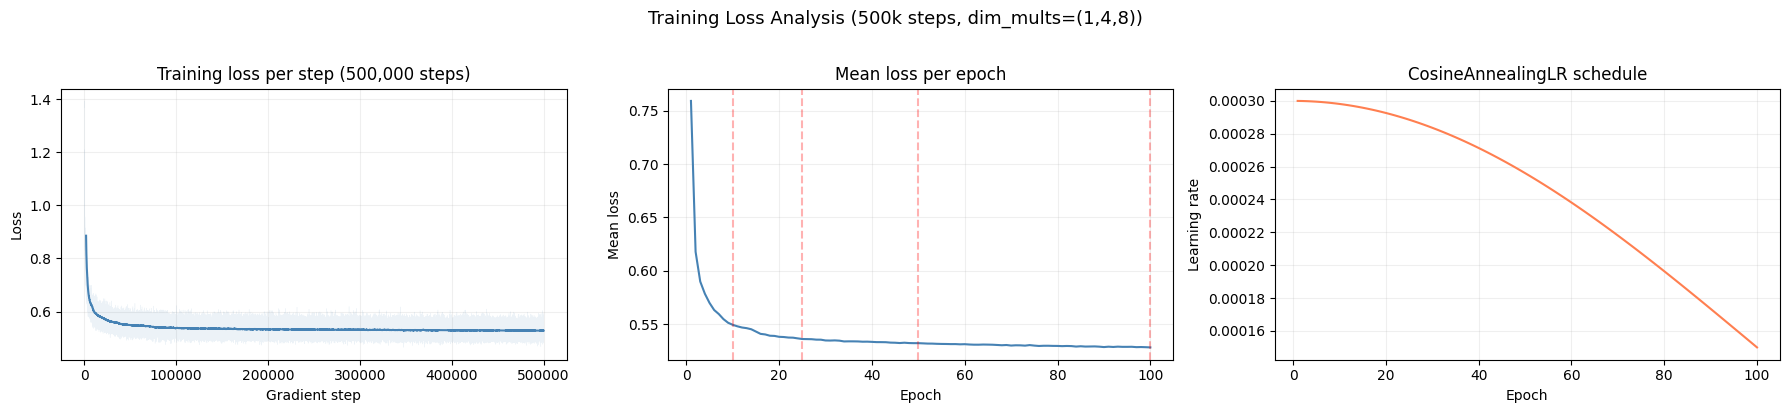


Convergence check:
  First 10% epochs mean loss:  0.589250
  Last 10% epochs mean loss:   0.528486
  Ratio (last/first):          0.8969


In [7]:
# --- Loss curve analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Raw loss per step (smoothed)
ax = axes[0]
ax.plot(all_losses, alpha=0.1, color="steelblue", linewidth=0.3)
window = min(2000, max(1, len(all_losses) // 10))
if window > 1:
    smoothed = np.convolve(all_losses, np.ones(window) / window, mode="valid")
    ax.plot(range(window - 1, len(all_losses)), smoothed, color="steelblue", linewidth=1.5)
ax.set_xlabel("Gradient step")
ax.set_ylabel("Loss")
ax.set_title(f"Training loss per step ({len(all_losses):,} steps)")
ax.grid(alpha=0.2)

# 2. Mean loss per epoch
ax = axes[1]
ax.plot(range(1, NUM_EPOCHS + 1), epoch_mean_losses, color="steelblue", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean loss")
ax.set_title("Mean loss per epoch")
ax.grid(alpha=0.2)
for ep in CHECKPOINT_EPOCHS:
    if ep <= len(epoch_mean_losses):
        ax.axvline(ep, color="red", alpha=0.3, linestyle="--")

# 3. LR schedule
ax = axes[2]
ax.plot(range(1, NUM_EPOCHS + 1), lr_history, color="coral", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_title("CosineAnnealingLR schedule")
ax.grid(alpha=0.2)

fig.suptitle("Training Loss Analysis (500k steps, dim_mults=(1,4,8))", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Convergence check
last_10pct = epoch_mean_losses[int(0.9 * NUM_EPOCHS):]
first_10pct = epoch_mean_losses[:int(0.1 * NUM_EPOCHS)]
print(f"\nConvergence check:")
print(f"  First 10% epochs mean loss:  {np.mean(first_10pct):.6f}")
print(f"  Last 10% epochs mean loss:   {np.mean(last_10pct):.6f}")
print(f"  Ratio (last/first):          {np.mean(last_10pct) / np.mean(first_10pct):.4f}")

## Chunk Quality at Each Checkpoint

**Target:** L2 < 1.0 before attempting stitching.

In [8]:
from src.latent_sope.eval.metrics import l2_chunk_error

test_batch = next(iter(dataloader))
test_batch_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in test_batch.items()}

cat_sf = torch.cat([test_batch_dev["states_from"], test_batch_dev["actions_from"]], dim=-1)
cat_st = torch.cat([test_batch_dev["states_to"][:, :-1, :], test_batch_dev["actions_to"]], dim=-1)
x_gt = torch.cat([cat_sf, cat_st], dim=1)
cond = diffuser.make_cond(test_batch_dev)

state_dim = diffuser.state_dim
chunk_results = {}

for ckpt_epoch in CHECKPOINT_EPOCHS:
    ckpt_file = ckpt_dir / f"sope_diffuser_epoch_{ckpt_epoch:04d}.pt"
    if not ckpt_file.exists():
        print(f"Checkpoint epoch {ckpt_epoch} not found, skipping.")
        continue

    payload = torch.load(str(ckpt_file), map_location=device, weights_only=False)
    diffuser.diffusion.load_state_dict(payload["diffusion_state_dict"])
    diffuser.diffusion.eval()

    with torch.no_grad():
        sample = diffuser.diffusion.conditional_sample(
            shape=x_gt.shape, cond=cond, guided=False, verbose=False,
        )
    x_hat = sample.trajectories

    x_gt_unnorm = diffuser.unnormalizer(x_gt).cpu().numpy()
    x_hat_unnorm = diffuser.unnormalizer(x_hat).cpu().numpy()

    err_s = l2_chunk_error(x_hat_unnorm[:, :, :state_dim], x_gt_unnorm[:, :, :state_dim])
    err_a = l2_chunk_error(x_hat_unnorm[:, :, state_dim:], x_gt_unnorm[:, :, state_dim:])

    chunk_results[ckpt_epoch] = {
        "state_l2": err_s.mean_l2,
        "state_l2_std": err_s.std_l2,
        "action_l2": err_a.mean_l2,
        "action_l2_std": err_a.std_l2,
        "rmse_per_dim": err_s.rmse_per_dim,
    }
    total_steps_at = ckpt_epoch * STEPS_PER_EPOCH
    print(f"Epoch {ckpt_epoch:4d} ({total_steps_at:6d} steps): "
          f"state L2 = {err_s.mean_l2:.4f} ± {err_s.std_l2:.4f}, "
          f"action L2 = {err_a.mean_l2:.4f} ± {err_a.std_l2:.4f}")

# Reload final
best_epoch = CHECKPOINT_EPOCHS[-1]
payload = torch.load(str(ckpt_dir / f"sope_diffuser_epoch_{best_epoch:04d}.pt"), map_location=device, weights_only=False)
diffuser.diffusion.load_state_dict(payload["diffusion_state_dict"])
diffuser.diffusion.eval()
print(f"\nLoaded epoch {best_epoch} for subsequent steps.")

                                                                                                    
1 / 256 [                                                            ]   0% | 8.2 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 15.3 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 21.7 Hz
t : 253
                                                                                                    
                                                                                                    
4 / 256 [   

                                                                                                    
                                                                                                    
12 / 256 [##                                                          ]   4% | 58.3 Hz
t : 244
                                                                                                    
                                                                                                    
13 / 256 [###                                                         ]   5% | 60.8 Hz
t : 243
                                                                                                    
                                                                                                    
14 / 256 [###                                                         ]   5% | 63.3 Hz
t : 242
                                                                                                    
        

                                                                                                    
                                                                                                    
28 / 256 [######                                                      ]  10% | 84.5 Hz
t : 228
                                                                                                    
                                                                                                    
29 / 256 [######                                                      ]  11% | 85.5 Hz
t : 227
                                                                                                    
                                                                                                    
30 / 256 [#######                                                     ]  11% | 86.5 Hz
t : 226
                                                                                                    
        

                                                                                                    
                                                                                                    
39 / 256 [#########                                                   ]  15% | 94.3 Hz
t : 217
                                                                                                    
                                                                                                    
40 / 256 [#########                                                   ]  15% | 95.0 Hz
t : 216
                                                                                                    
                                                                                                    
41 / 256 [#########                                                   ]  16% | 95.7 Hz
t : 215
                                                                                                    
        

                                                                                                    
                                                                                                    
56 / 256 [#############                                               ]  21% | 103.8 Hz
t : 200
                                                                                                    
                                                                                                    
57 / 256 [#############                                               ]  22% | 104.1 Hz
t : 199
                                                                                                    
                                                                                                    
58 / 256 [#############                                               ]  22% | 104.5 Hz
t : 198
                                                                                                    
     

...

                                                                                                    
                                                                                                    
130 / 256 [##############################                              ]  50% | 133.5 Hz
t : 126
                                                                                                    
                                                                                                    
131 / 256 [##############################                              ]  51% | 133.4 Hz
t : 125
                                                                                                    
                                                                                                    
132 / 256 [##############################                              ]  51% | 133.5 Hz
t : 124
                                                                                                    
  

                                                                                                    
                                                                                                    
158 / 256 [#####################################                       ]  61% | 134.3 Hz
t : 98
                                                                                                    
                                                                                                    
159 / 256 [#####################################                       ]  62% | 134.3 Hz
t : 97
                                                                                                    
                                                                                                    
160 / 256 [#####################################                       ]  62% | 134.3 Hz
t : 96
                                                                                                    
     

                                                                                                    
                                                                                                    
186 / 256 [###########################################                 ]  72% | 134.4 Hz
t : 70
                                                                                                    
                                                                                                    
187 / 256 [###########################################                 ]  73% | 134.3 Hz
t : 69
                                                                                                    
                                                                                                    
188 / 256 [############################################                ]  73% | 134.3 Hz
t : 68
                                                                                                    
     

                                                                                                    
                                                                                                    
214 / 256 [##################################################          ]  83% | 133.8 Hz
t : 42
                                                                                                    
                                                                                                    
215 / 256 [##################################################          ]  83% | 133.5 Hz
t : 41
                                                                                                    
                                                                                                    
216 / 256 [##################################################          ]  84% | 133.6 Hz
t : 40
                                                                                                    
     

                                                                                                    
                                                                                                    
242 / 256 [########################################################    ]  94% | 133.9 Hz
t : 14
                                                                                                    
                                                                                                    
243 / 256 [########################################################    ]  94% | 133.8 Hz
t : 13
                                                                                                    
                                                                                                    
244 / 256 [#########################################################   ]  95% | 133.8 Hz
t : 12
                                                                                                    
     

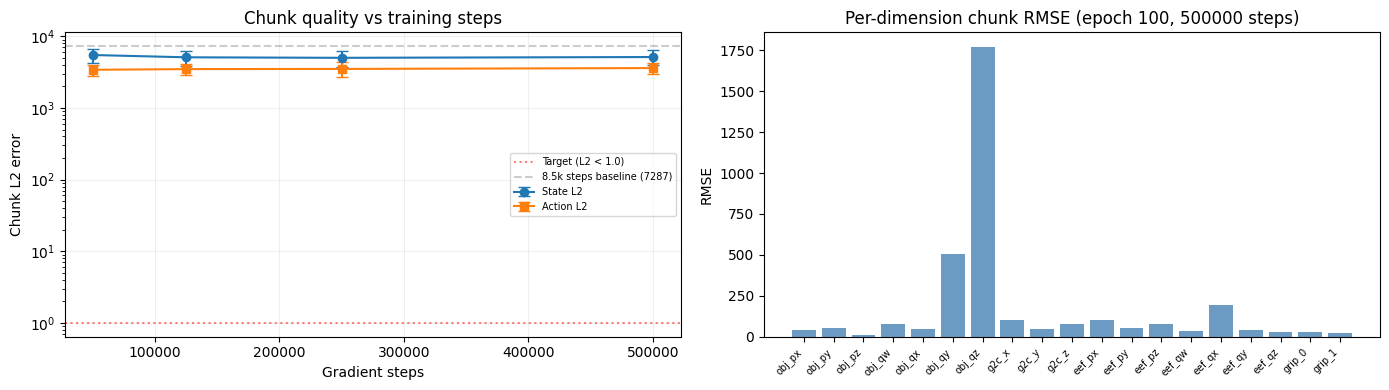


Final chunk L2 (states): 5139.5566
FAIL: Chunk quality still poor.


In [9]:
# --- Chunk quality progression plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_list = sorted(chunk_results.keys())
steps_list = [e * STEPS_PER_EPOCH for e in epochs_list]
state_l2s = [chunk_results[e]["state_l2"] for e in epochs_list]
action_l2s = [chunk_results[e]["action_l2"] for e in epochs_list]
state_stds = [chunk_results[e]["state_l2_std"] for e in epochs_list]
action_stds = [chunk_results[e]["action_l2_std"] for e in epochs_list]

ax = axes[0]
ax.errorbar(steps_list, state_l2s, yerr=state_stds, marker="o", label="State L2", capsize=4)
ax.errorbar(steps_list, action_l2s, yerr=action_stds, marker="s", label="Action L2", capsize=4)
ax.axhline(1.0, color="red", linestyle=":", alpha=0.5, label="Target (L2 < 1.0)")
# Reference: 8.5k steps result
ax.axhline(7287, color="gray", linestyle="--", alpha=0.4, label="8.5k steps baseline (7287)")
ax.set_xlabel("Gradient steps")
ax.set_ylabel("Chunk L2 error")
ax.set_title("Chunk quality vs training steps")
ax.legend(fontsize=7)
ax.set_yscale("log")
ax.grid(alpha=0.2)

# Per-dim RMSE at final checkpoint
ax = axes[1]
dim_labels = [
    "obj_px", "obj_py", "obj_pz", "obj_qw", "obj_qx", "obj_qy", "obj_qz",
    "g2c_x", "g2c_y", "g2c_z", "eef_px", "eef_py", "eef_pz",
    "eef_qw", "eef_qx", "eef_qy", "eef_qz", "grip_0", "grip_1",
]
final_rmse = chunk_results[epochs_list[-1]]["rmse_per_dim"]
ax.bar(range(len(final_rmse)), final_rmse, color="steelblue", alpha=0.8)
ax.set_xticks(range(len(dim_labels)))
ax.set_xticklabels(dim_labels, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("RMSE")
ax.set_title(f"Per-dimension chunk RMSE (epoch {epochs_list[-1]}, {steps_list[-1]} steps)")

plt.tight_layout()
plt.show()

final_l2 = chunk_results[epochs_list[-1]]["state_l2"]
print(f"\nFinal chunk L2 (states): {final_l2:.4f}")
if final_l2 < 1.0:
    print("PASS: Chunk quality meets target. Proceeding to stitching.")
elif final_l2 < 10.0:
    print("MARGINAL: Chunk quality improved but still above target.")
else:
    print("FAIL: Chunk quality still poor.")

## Step 5: Generate Synthetic Trajectories via Stitching

In [10]:
NUM_TRAJS = 50
MAX_LENGTH = HORIZON

init_states = []
for i in range(NUM_TRAJS):
    traj_i = load_rollout_latents(rollout_paths[i % len(rollout_paths)])
    latents = traj_i.latents
    if latents.ndim == 3:
        latents = latents[:, 0, :]
    init_states.append(latents[0])

init_states_t = torch.tensor(np.stack(init_states), dtype=torch.float32)

print(f"Generating {NUM_TRAJS} stitched trajectories (max {MAX_LENGTH} steps)...\n")

syn_states, syn_actions, end_indices = diffuser.generate_full_trajectory(
    initial_states=init_states_t,
    max_length=MAX_LENGTH,
    guided=False,
    verbose=False,
)

print(f"Generated {NUM_TRAJS} trajectories:")
print(f"  states shape: {syn_states.shape}")
print(f"  actions shape: {syn_actions.shape}")
print(f"  state range: [{syn_states.min():.2f}, {syn_states.max():.2f}]")
print(f"  action range: [{syn_actions.min():.2f}, {syn_actions.max():.2f}]")

Generating 50 stitched trajectories (max 60 steps)...


                                                                                                    
1 / 256 [                                                            ]   0% | 46.0 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 67.8 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 80.8 Hz
t : 253
                                                                                                    
                                                        

                                                                                                    
                                                                                                    
25 / 256 [#####                                                       ]   9% | 123.7 Hz
t : 231
                                                                                                    
                                                                                                    
26 / 256 [######                                                      ]  10% | 123.8 Hz
t : 230
                                                                                                    
                                                                                                    
27 / 256 [######                                                      ]  10% | 124.2 Hz
t : 229
                                                                                                    
     

                                                                                                    
                                                                                                    
52 / 256 [############                                                ]  20% | 127.5 Hz
t : 204
                                                                                                    
                                                                                                    
53 / 256 [############                                                ]  20% | 127.5 Hz
t : 203
                                                                                                    
                                                                                                    
54 / 256 [############                                                ]  21% | 127.6 Hz
t : 202
                                                                                                    
     

                                                                                                    
                                                                                                    
79 / 256 [##################                                          ]  30% | 129.4 Hz
t : 177
                                                                                                    
                                                                                                    
80 / 256 [##################                                          ]  31% | 129.3 Hz
t : 176
                                                                                                    
                                                                                                    
81 / 256 [##################                                          ]  31% | 129.4 Hz
t : 175
                                                                                                    
     

                                                                                                    
                                                                                                    
106 / 256 [########################                                    ]  41% | 129.9 Hz
t : 150
                                                                                                    
                                                                                                    
107 / 256 [#########################                                   ]  41% | 129.7 Hz
t : 149
                                                                                                    
                                                                                                    
108 / 256 [#########################                                   ]  42% | 130.2 Hz
t : 148
                                                                                                    
  

...

                                                                                                    
                                                                                                    
117 / 256 [###########################                                 ]  45% | 134.2 Hz
t : 139
                                                                                                    
                                                                                                    
118 / 256 [###########################                                 ]  46% | 133.9 Hz
t : 138
                                                                                                    
                                                                                                    
119 / 256 [###########################                                 ]  46% | 134.1 Hz
t : 137
                                                                                                    
  

                                                                                                    
                                                                                                    
145 / 256 [#################################                           ]  56% | 135.4 Hz
t : 111
                                                                                                    
                                                                                                    
146 / 256 [##################################                          ]  57% | 135.3 Hz
t : 110
                                                                                                    
                                                                                                    
147 / 256 [##################################                          ]  57% | 135.3 Hz
t : 109
                                                                                                    
  

                                                                                                    
                                                                                                    
173 / 256 [########################################                    ]  67% | 135.6 Hz
t : 83
                                                                                                    
                                                                                                    
174 / 256 [########################################                    ]  67% | 135.5 Hz
t : 82
                                                                                                    
                                                                                                    
175 / 256 [#########################################                   ]  68% | 135.5 Hz
t : 81
                                                                                                    
     

                                                                                                    
                                                                                                    
201 / 256 [###############################################             ]  78% | 113.7 Hz
t : 55
                                                                                                    
                                                                                                    
202 / 256 [###############################################             ]  78% | 120.3 Hz
t : 54
                                                                                                    
                                                                                                    
203 / 256 [###############################################             ]  79% | 124.6 Hz
t : 53
                                                                                                    
     

                                                                                                    
                                                                                                    
229 / 256 [#####################################################       ]  89% | 134.7 Hz
t : 27
                                                                                                    
                                                                                                    
230 / 256 [#####################################################       ]  89% | 134.4 Hz
t : 26
                                                                                                    
                                                                                                    
231 / 256 [######################################################      ]  90% | 134.5 Hz
t : 25
                                                                                                    
     

## Diagnostics: Per-Step MSE + Clamped Baseline

In [11]:
from src.latent_sope.eval.metrics import trajectory_reconstruction_mse

# Load real trajectories
real_states_list, real_actions_list, real_rewards_list = [], [], []
for i in range(NUM_TRAJS):
    traj_i = load_rollout_latents(rollout_paths[i % len(rollout_paths)])
    latents = traj_i.latents
    if latents.ndim == 3:
        latents = latents[:, 0, :]
    actions, rewards = traj_i.actions, traj_i.rewards
    T = latents.shape[0]
    if T >= MAX_LENGTH:
        real_states_list.append(latents[:MAX_LENGTH])
        real_actions_list.append(actions[:MAX_LENGTH])
        real_rewards_list.append(rewards[:MAX_LENGTH])
    else:
        real_states_list.append(np.pad(latents, ((0, MAX_LENGTH - T), (0, 0))))
        real_actions_list.append(np.pad(actions, ((0, MAX_LENGTH - T), (0, 0))))
        real_rewards_list.append(np.pad(rewards, (0, MAX_LENGTH - T)))

real_states = np.stack(real_states_list).astype(np.float32)
real_actions = np.stack(real_actions_list).astype(np.float32)
real_rewards = np.stack(real_rewards_list).astype(np.float32)

recon = trajectory_reconstruction_mse(real_states, syn_states, real_actions, syn_actions, end_indices)
print(f"Trajectory Reconstruction MSE ({recon.num_trajectories} trajs, {recon.trajectory_length} steps):")
print(f"  State MSE:  {recon.state_mse:.6f}")
print(f"  Action MSE: {recon.action_mse:.6f}")

Trajectory Reconstruction MSE (50 trajs, 60 steps):
  State MSE:  8770911.681123
  Action MSE: 8845849.551238


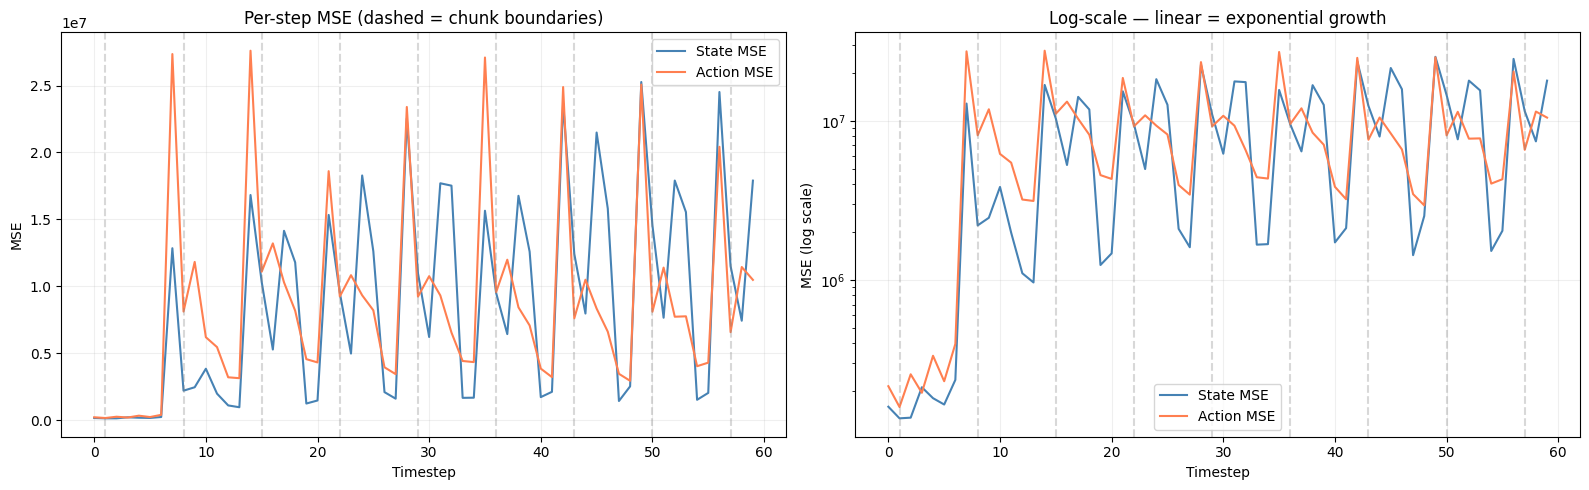

Error growth: 65.8x total over 8 chunks
  Per-chunk growth factor: 1.82x


In [12]:
# --- Per-step MSE with chunk boundaries ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(recon.state_mse_per_step, color="steelblue", linewidth=1.5, label="State MSE")
ax.plot(recon.action_mse_per_step, color="coral", linewidth=1.5, label="Action MSE")
chunk_size = diffusion_config.chunk_horizon
frame_stack = diffusion_config.frame_stack
for boundary in range(frame_stack, MAX_LENGTH, chunk_size):
    ax.axvline(boundary, color="gray", alpha=0.3, linestyle="--")
ax.set_xlabel("Timestep")
ax.set_ylabel("MSE")
ax.set_title("Per-step MSE (dashed = chunk boundaries)")
ax.legend()
ax.grid(alpha=0.2)

ax = axes[1]
state_mse_clipped = np.clip(recon.state_mse_per_step, 1e-10, None)
action_mse_clipped = np.clip(recon.action_mse_per_step, 1e-10, None)
ax.semilogy(state_mse_clipped, color="steelblue", linewidth=1.5, label="State MSE")
ax.semilogy(action_mse_clipped, color="coral", linewidth=1.5, label="Action MSE")
for boundary in range(frame_stack, MAX_LENGTH, chunk_size):
    ax.axvline(boundary, color="gray", alpha=0.3, linestyle="--")
ax.set_xlabel("Timestep")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Log-scale — linear = exponential growth")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

if len(recon.state_mse_per_step) > 10:
    first_chunk_mse = np.mean(recon.state_mse_per_step[:chunk_size])
    last_chunk_mse = np.mean(recon.state_mse_per_step[-chunk_size:])
    n_chunks = MAX_LENGTH // chunk_size
    if first_chunk_mse > 0:
        growth_factor = last_chunk_mse / first_chunk_mse
        per_chunk_growth = growth_factor ** (1.0 / max(n_chunks - 1, 1))
        print(f"Error growth: {growth_factor:.1f}x total over {n_chunks} chunks")
        print(f"  Per-chunk growth factor: {per_chunk_growth:.2f}x")

In [13]:
# --- Clamped-output baseline ---
from src.latent_sope.eval.reward_model import LiftRewardFn, score_trajectories_gt, make_lift_encoder
from src.latent_sope.eval.metrics import ope_eval

real_state_min = real_states.min(axis=(0, 1))
real_state_max = real_states.max(axis=(0, 1))
real_action_min = real_actions.min(axis=(0, 1))
real_action_max = real_actions.max(axis=(0, 1))

syn_states_clamped = np.clip(syn_states, real_state_min, real_state_max)
syn_actions_clamped = np.clip(syn_actions, real_action_min, real_action_max)

n_clamped = ((syn_states < real_state_min) | (syn_states > real_state_max)).sum()
print(f"State range: [{syn_states.min():.2f}, {syn_states.max():.2f}] -> clamped to [{syn_states_clamped.min():.2f}, {syn_states_clamped.max():.2f}]")
print(f"Clamped {n_clamped}/{syn_states.size} state values ({100*n_clamped/syn_states.size:.1f}%)")

encoder = make_lift_encoder(obs_keys=obs_keys)
reward_fn = LiftRewardFn(table_height=0.8, height_threshold=0.04)

returns_unclamped, _ = score_trajectories_gt(
    reward_fn=reward_fn, encoder=encoder,
    states=syn_states, actions=syn_actions, gamma=gamma,
)
ope_unclamped = ope_eval(oracle_value, returns_unclamped)

returns_clamped, _ = score_trajectories_gt(
    reward_fn=reward_fn, encoder=encoder,
    states=syn_states_clamped, actions=syn_actions_clamped, gamma=gamma,
)
ope_clamped = ope_eval(oracle_value, returns_clamped)

real_success_rate = np.mean([float((real_states[i, :, 2] > 0.84).any()) for i in range(NUM_TRAJS)])
syn_success_unclamped = np.mean([float((syn_states[i, :, 2] > 0.84).any()) for i in range(NUM_TRAJS)])
syn_success_clamped = np.mean([float((syn_states_clamped[i, :, 2] > 0.84).any()) for i in range(NUM_TRAJS)])

print(f"\n{'':30s} {'Unclamped':>12s} {'Clamped':>12s} {'Oracle':>12s}")
print("-" * 70)
print(f"{'OPE estimate':30s} {ope_unclamped.ope_estimate:12.3f} {ope_clamped.ope_estimate:12.3f} {oracle_value:12.3f}")
print(f"{'OPE std':30s} {ope_unclamped.ope_std:12.3f} {ope_clamped.ope_std:12.3f} {'':>12s}")
print(f"{'Relative error':30s} {ope_unclamped.relative_error:11.1%} {ope_clamped.relative_error:11.1%} {'':>12s}")
print(f"{'Success rate (real)':30s} {real_success_rate:11.1%}")
print(f"{'Success rate (unclamped)':30s} {syn_success_unclamped:11.1%}")
print(f"{'Success rate (clamped)':30s} {syn_success_clamped:11.1%}")

State range: [-49101.21, 38081.08] -> clamped to [-1.00, 1.04]
Clamped 56819/57000 state values (99.7%)

                                  Unclamped      Clamped       Oracle
----------------------------------------------------------------------
OPE estimate                         30.520        0.000        0.540
OPE std                               3.233        0.000             
Relative error                     5551.9%      100.0%             
Success rate (real)                   0.0%
Success rate (unclamped)            100.0%
Success rate (clamped)                0.0%


## Trajectory Sanity Checks

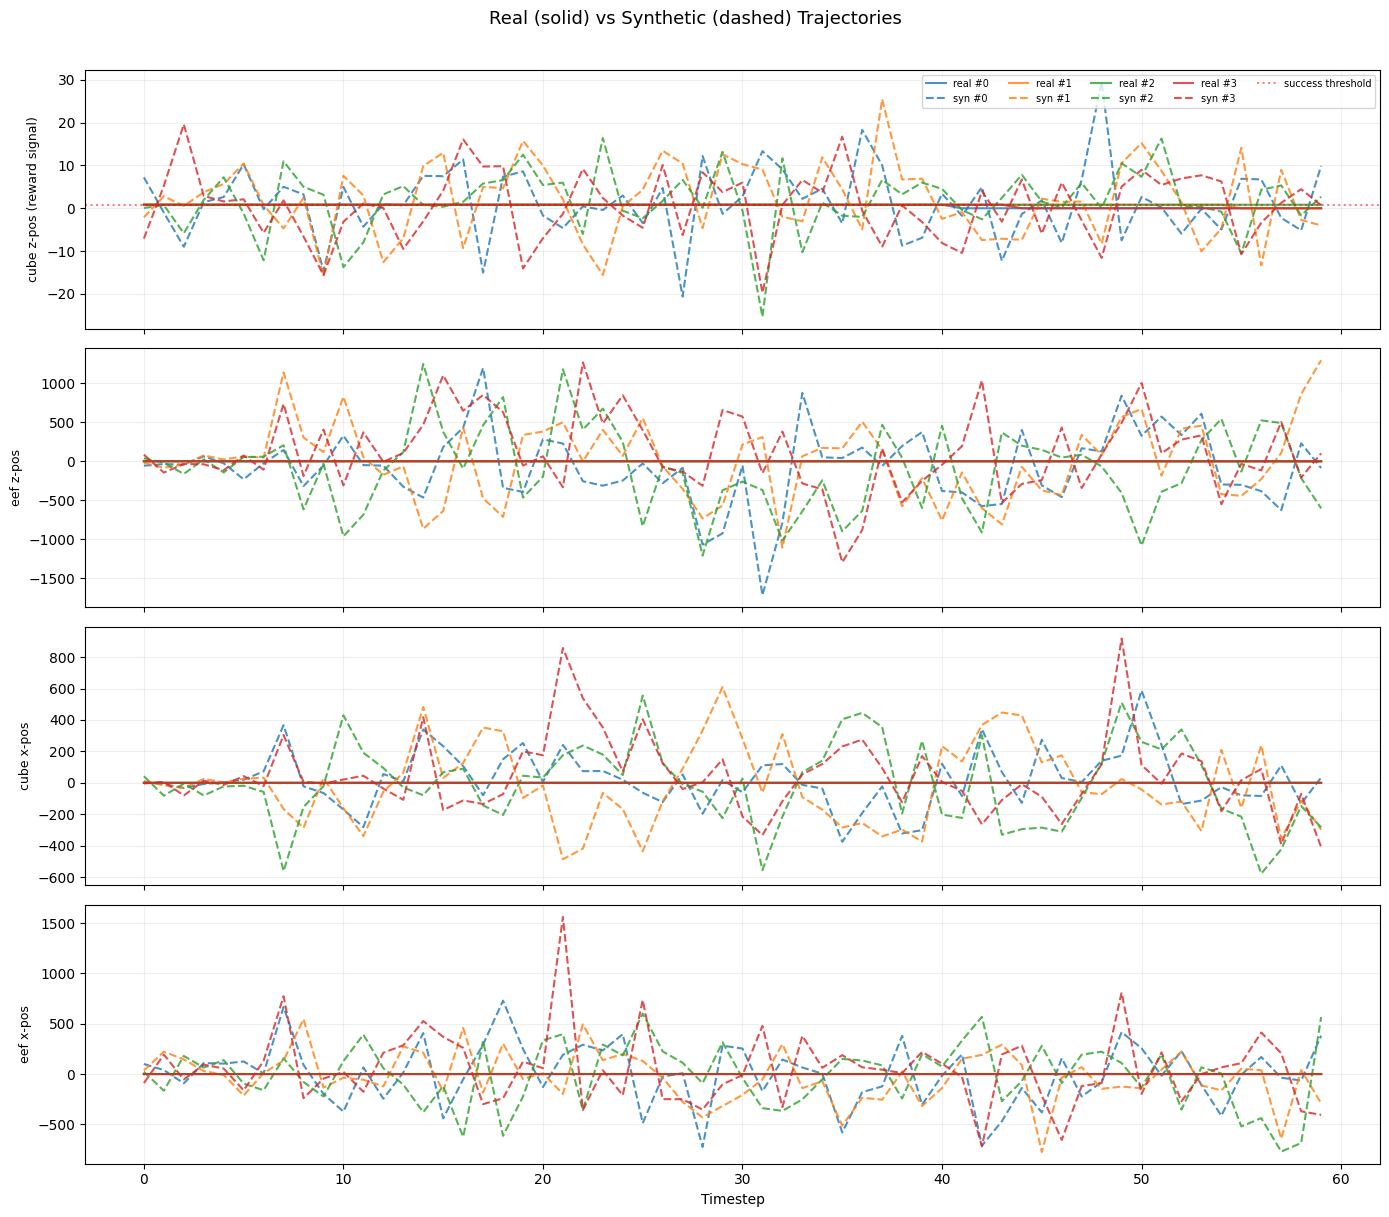

In [14]:
# --- Visual: real vs synthetic trajectories ---
key_dims = [
    (2, "cube z-pos (reward signal)"),
    (12, "eef z-pos"),
    (0, "cube x-pos"),
    (10, "eef x-pos"),
]
n_show = min(4, NUM_TRAJS)

fig, axes = plt.subplots(len(key_dims), 1, figsize=(14, 3 * len(key_dims)), sharex=True)
for row, (dim_idx, dim_name) in enumerate(key_dims):
    ax = axes[row]
    for b in range(n_show):
        ax.plot(real_states[b, :, dim_idx], color=f"C{b}", alpha=0.8, linewidth=1.5,
                label=f"real #{b}" if row == 0 else None)
        ax.plot(syn_states[b, :, dim_idx], color=f"C{b}", alpha=0.8, linewidth=1.5,
                linestyle="--", label=f"syn #{b}" if row == 0 else None)
    ax.set_ylabel(dim_name, fontsize=9)
    if dim_idx == 2:
        ax.axhline(0.84, color="red", linestyle=":", alpha=0.5,
                   label="success threshold" if row == 0 else None)
    ax.grid(alpha=0.2)

axes[0].legend(ncol=n_show + 1, fontsize=7, loc="upper right")
axes[-1].set_xlabel("Timestep")
fig.suptitle("Real (solid) vs Synthetic (dashed) Trajectories", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

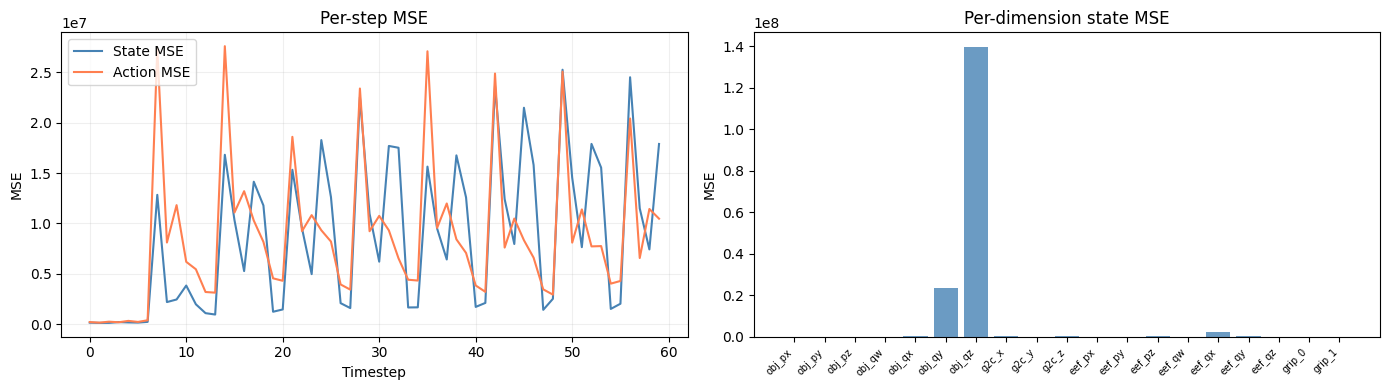


Dim         Real mean   Syn mean   Real std    Syn std       Real [min,max]        Syn [min,max]
------------------------------------------------------------------------------------------------------
obj_px         0.0037    20.4034     0.0162   212.9250 [ -0.028,   0.040]  [-924.945, 1044.980]
obj_py         0.0031   -17.1137     0.0152   185.7330 [ -0.032,   0.029]  [-701.057, 673.249]
obj_pz         0.7323     0.7663     0.2553     8.2549 [  0.000,   0.835]  [-26.258,  29.555]
obj_qw         0.0014    -4.7971     0.0168    83.3583 [ -0.187,   0.232]  [-306.004, 264.333]
obj_qx         0.0032  -137.1200     0.0326   418.9666 [ -0.171,   0.443]  [-2240.666, 1720.403]
obj_qy         0.5890  1364.7985     0.3447  4628.4282 [  0.000,   1.000]  [-20280.424, 24489.107]
obj_qz         0.1420 -3936.2107     0.6360 11145.1113 [ -0.998,   0.998]  [-49101.211, 38081.078]
g2c_x          0.0168    -7.8471     0.0380   332.1296 [ -0.044,   0.140]  [-1996.720, 1033.724]
g2c_y          0.0019   -37

In [15]:
# --- Per-dim MSE + marginal stats ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(recon.state_mse_per_step, color="steelblue", linewidth=1.5, label="State MSE")
ax1.plot(recon.action_mse_per_step, color="coral", linewidth=1.5, label="Action MSE")
ax1.set_xlabel("Timestep")
ax1.set_ylabel("MSE")
ax1.set_title("Per-step MSE")
ax1.legend()
ax1.grid(alpha=0.2)

dim_labels = [
    "obj_px", "obj_py", "obj_pz", "obj_qw", "obj_qx", "obj_qy", "obj_qz",
    "g2c_x", "g2c_y", "g2c_z", "eef_px", "eef_py", "eef_pz",
    "eef_qw", "eef_qx", "eef_qy", "eef_qz", "grip_0", "grip_1",
]
ax2.bar(range(len(recon.state_mse_per_dim)), recon.state_mse_per_dim, color="steelblue", alpha=0.8)
ax2.set_xticks(range(len(dim_labels)))
ax2.set_xticklabels(dim_labels, rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("MSE")
ax2.set_title("Per-dimension state MSE")
plt.tight_layout()
plt.show()

# Marginal statistics
print(f"\n{'Dim':<10} {'Real mean':>10} {'Syn mean':>10} {'Real std':>10} {'Syn std':>10} {'Real [min,max]':>20} {'Syn [min,max]':>20}")
print("-" * 102)
for d, label in enumerate(dim_labels):
    r, s = real_states[:, :, d], syn_states[:, :, d]
    print(f"{label:<10} {r.mean():10.4f} {s.mean():10.4f} {r.std():10.4f} {s.std():10.4f} "
          f"[{r.min():7.3f}, {r.max():7.3f}]  [{s.min():7.3f}, {s.max():7.3f}]")

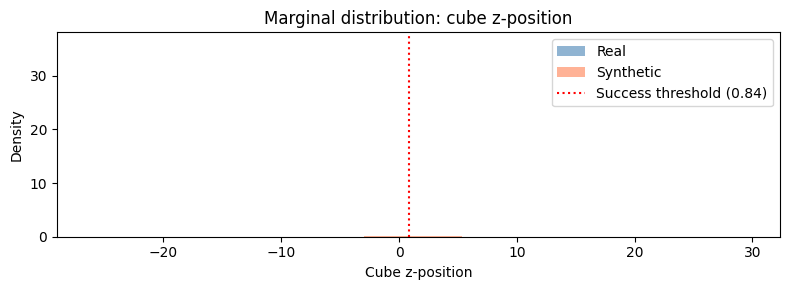

In [16]:
# --- Cube z histogram ---
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(real_states[:, :, 2].ravel(), bins=60, alpha=0.6, density=True, label="Real", color="steelblue")
ax.hist(syn_states[:, :, 2].ravel(), bins=60, alpha=0.6, density=True, label="Synthetic", color="coral")
ax.axvline(0.84, color="red", linestyle=":", label="Success threshold (0.84)")
ax.set_xlabel("Cube z-position")
ax.set_ylabel("Density")
ax.set_title("Marginal distribution: cube z-position")
ax.legend()
plt.tight_layout()
plt.show()

## OPE Summary

OPE Evaluation — 500k steps, dim_mults=(1,4,8)
  Oracle V^pi:           0.540
  OPE estimate:          30.520 (std=3.233)
  OPE clamped:           0.000 (std=0.000)
  Relative error:        5551.85%
  Clamped rel. error:    100.00%


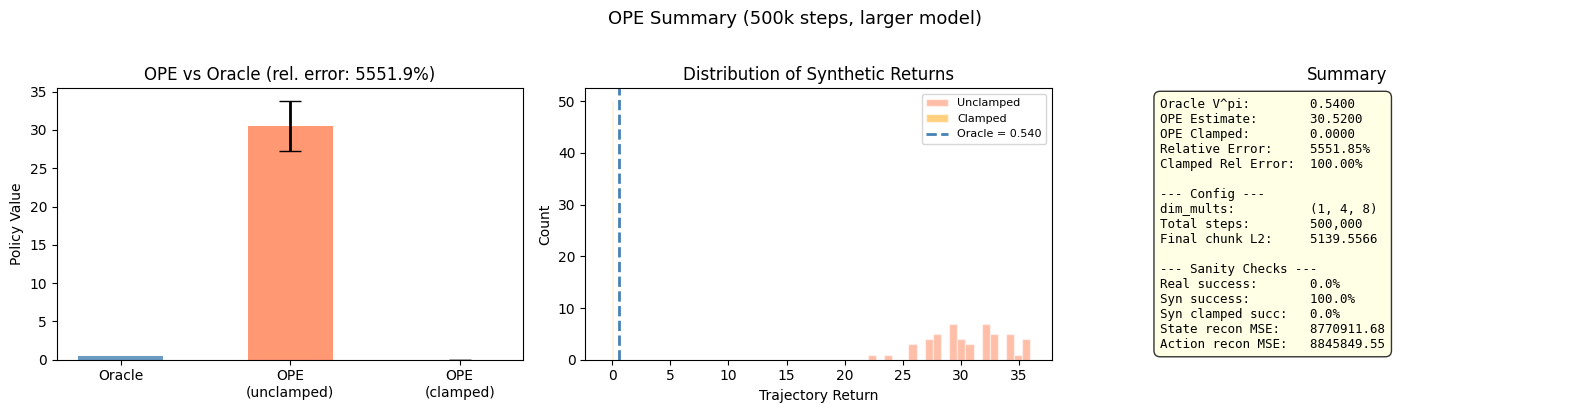

In [17]:
result = ope_unclamped
final_l2 = chunk_results[sorted(chunk_results.keys())[-1]]["state_l2"]

print("=" * 60)
print("OPE Evaluation — 500k steps, dim_mults=(1,4,8)")
print("=" * 60)
print(f"  Oracle V^pi:           {result.oracle_value:.3f}")
print(f"  OPE estimate:          {result.ope_estimate:.3f} (std={result.ope_std:.3f})")
print(f"  OPE clamped:           {ope_clamped.ope_estimate:.3f} (std={ope_clamped.ope_std:.3f})")
print(f"  Relative error:        {result.relative_error:.2%}")
print(f"  Clamped rel. error:    {ope_clamped.relative_error:.2%}")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.bar(
    ["Oracle", "OPE\n(unclamped)", "OPE\n(clamped)"],
    [result.oracle_value, result.ope_estimate, ope_clamped.ope_estimate],
    color=["steelblue", "coral", "orange"], alpha=0.8, width=0.5,
)
ax.errorbar(1, result.ope_estimate, yerr=result.ope_std, fmt="none", color="black", capsize=8, linewidth=2)
ax.errorbar(2, ope_clamped.ope_estimate, yerr=ope_clamped.ope_std, fmt="none", color="black", capsize=8, linewidth=2)
ax.set_ylabel("Policy Value")
ax.set_title(f"OPE vs Oracle (rel. error: {result.relative_error:.1%})")

ax = axes[1]
ax.hist(returns_unclamped, bins=20, alpha=0.5, color="coral", edgecolor="white", label="Unclamped")
ax.hist(returns_clamped, bins=20, alpha=0.5, color="orange", edgecolor="white", label="Clamped")
ax.axvline(result.oracle_value, color="steelblue", linewidth=2, linestyle="--", label=f"Oracle = {result.oracle_value:.3f}")
ax.set_xlabel("Trajectory Return")
ax.set_ylabel("Count")
ax.set_title("Distribution of Synthetic Returns")
ax.legend(fontsize=8)

ax = axes[2]
ax.axis("off")
summary = (
    f"Oracle V^pi:        {result.oracle_value:.4f}\n"
    f"OPE Estimate:       {result.ope_estimate:.4f}\n"
    f"OPE Clamped:        {ope_clamped.ope_estimate:.4f}\n"
    f"Relative Error:     {result.relative_error:.2%}\n"
    f"Clamped Rel Error:  {ope_clamped.relative_error:.2%}\n"
    f"\n--- Config ---\n"
    f"dim_mults:          (1, 4, 8)\n"
    f"Total steps:        {len(all_losses):,}\n"
    f"Final chunk L2:     {final_l2:.4f}\n"
    f"\n--- Sanity Checks ---\n"
    f"Real success:       {real_success_rate:.1%}\n"
    f"Syn success:        {syn_success_unclamped:.1%}\n"
    f"Syn clamped succ:   {syn_success_clamped:.1%}\n"
    f"State recon MSE:    {recon.state_mse:.2f}\n"
    f"Action recon MSE:   {recon.action_mse:.2f}"
)
ax.text(0.1, 0.5, summary, transform=ax.transAxes, fontsize=9,
        verticalalignment="center", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))
ax.set_title("Summary")

fig.suptitle("OPE Summary (500k steps, larger model)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Conclusions

Fill in after running:

**Comparison to 8.5k steps baseline:**
- Chunk L2: 7287 → ?
- Trajectory state MSE: 1,175,015 → ?
- OPE relative error: 5333% → ?
- % values clamped: 99.7% → ?

**If converged and chunk L2 < 1.0:**
- Pipeline is validated. Proceed to Step 4 (policy guidance).
- Scale to multi-policy OPE evaluation.

**If still not converged:**
- Try attention=True in TemporalUnet
- Try larger batch size (128, matching SOPE)
- Collect more rollouts (200+) for greater data diversity
- Investigate whether 19-dim latent space is too complex — try dropping quaternion dims